# Neural Networks and Matrices

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V07 — "Neural Networks and Matrices" (DeepLearning.AI).*

The Week 3 capstone: neural networks — among the most powerful ML models — are built largely on **matrix products** and the **dot product**. We build a concrete example from scratch:

- A **spam classifier**: word scores, a threshold, and the dot product.
- Running **all predictions at once** with a matrix-vector product.
- Rewriting the threshold as a **bias**.
- The **AND** operator as a **perceptron** (one-layer neural network), and the general perceptron with weights, bias, and an activation function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. A spam classifier from word scores

Two words are telltale for spam: **lottery** and **win**. We count how often each appears in an email and assign each word a **score**. The **score of a sentence** is the sum of word scores, counting repetitions.

> Example: with scores lottery $=3$, win $=2$, the sentence *"win win the lottery"* scores $2+2+3 = 7$ (the word *the* contributes nothing).

**Rule:** if a sentence's score exceeds a **threshold**, classify it as spam. The goal is to pick the best scores + threshold so the classifier matches the data. For this data set a **perfect** choice exists:

$$ \text{score}(\text{lottery}) = 1, \quad \text{score}(\text{win}) = 1, \quad \text{threshold} = 1.5. $$

*(The table below is an illustrative reconstruction of the lecture's data set, consistent with the examples given.)*

In [2]:
# columns: [lottery_count, win_count],  label 1 = spam
X = np.array([[1, 2],
              [2, 1],   # row 2 in the video: dot with model = 3 -> spam
              [0, 0],
              [1, 0],
              [0, 1],   # row 5 in the video: dot = 1 -> not spam
              [1, 1],
              [2, 0],
              [0, 2]])
spam = np.array([1, 1, 0, 0, 0, 1, 1, 1])   # ground truth

model = np.array([1, 1])   # scores for [lottery, win]
threshold = 1.5

print('sentence  score  pred  truth')
for row, y in zip(X, spam):
    score = row @ model
    pred = int(score > threshold)
    print(f'{row}     {score:>2}     {pred}     {y}')

sentence  score  pred  truth
[1 2]      3     1     1
[2 1]      3     1     1
[0 0]      0     0     0
[1 0]      1     0     0
[0 1]      1     0     0
[1 1]      2     1     1
[2 0]      2     1     1
[0 2]      2     1     1


## 2. All predictions at once: a matrix $\times$ vector

Instead of looping row by row, stack all sentences into a **matrix** $X$ and multiply by the **model vector** — one matrix-vector product yields **every** score. Then apply the threshold check element-wise.

If you had more words, you'd simply have a **wider matrix** and a **longer model vector** — the mechanism is identical.

In [3]:
scores = X @ model                 # all sentence scores in one shot
predictions = (scores > threshold).astype(int)
print('scores      =', scores)
print('predictions =', predictions)
print('ground truth=', spam)
print('perfect classifier:', np.array_equal(predictions, spam))

scores      = [3 3 0 1 1 2 2 2]
predictions = [1 1 0 0 0 1 1 1]
ground truth= [1 1 0 0 0 1 1 1]
perfect classifier: True


## 3. Geometric view: a linear classifier

Plot each email by (lottery count, win count). A **straight line** separates spam from non-spam — this is the simplest **neural network** (one layer), also called a **linear classifier**. The boundary is exactly the scores-equal-threshold line:

$$ 1\cdot\text{lottery} + 1\cdot\text{win} = 1.5. $$

It splits the plane into a **positive region** (score $>$ threshold $\Rightarrow$ spam) and a **negative region** (score $<$ threshold $\Rightarrow$ not spam). The model makes sense: more spammy words $\Rightarrow$ higher score $\Rightarrow$ more likely spam.

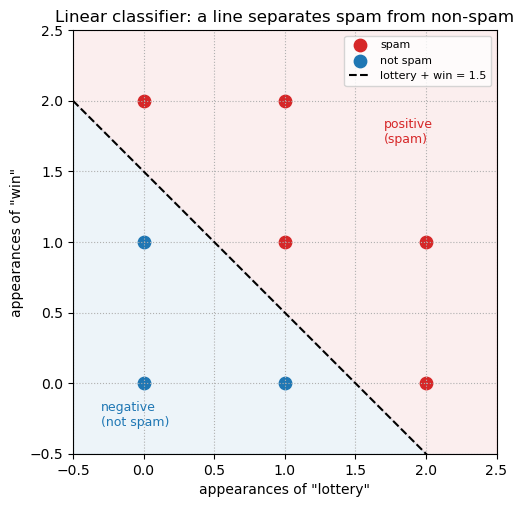

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
spam_pts = X[spam == 1]; ham_pts = X[spam == 0]
ax.scatter(spam_pts[:, 0], spam_pts[:, 1], color='C3', s=80, label='spam')
ax.scatter(ham_pts[:, 0], ham_pts[:, 1], color='C0', s=80, label='not spam')

# boundary line: lottery + win = 1.5  ->  win = 1.5 - lottery
xs = np.linspace(-0.5, 2.5, 50)
ax.plot(xs, 1.5 - xs, 'k--', label='lottery + win = 1.5')
ax.fill_between(xs, 1.5 - xs, 3, color='C3', alpha=0.08)
ax.fill_between(xs, -0.5, 1.5 - xs, color='C0', alpha=0.08)
ax.text(1.7, 1.7, 'positive\n(spam)', color='C3', fontsize=9)
ax.text(-0.3, -0.3, 'negative\n(not spam)', color='C0', fontsize=9)

ax.set_xlabel('appearances of "lottery"'); ax.set_ylabel('appearances of "win"')
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='upper right', fontsize=8)
ax.set_title('Linear classifier: a line separates spam from non-spam')
plt.show()

## 4. Threshold as a bias

Checking *score $> 1.5$* is the same as checking *score $- 1.5 > 0$*. That constant $-1.5$ is called the **bias**. To fold it into the matrix multiplication:

- add a **column of $1$s** to the data matrix, and
- add a **bias entry** ($-1.5$) to the model vector.

Now you just check whether the result is **positive or negative** (compare to $0$) instead of to a threshold — the same classifier. Neural networks usually use a **bias** rather than a threshold.

In [5]:
X_bias = np.hstack([X, np.ones((X.shape[0], 1))])   # append a column of 1s
model_bias = np.array([1, 1, -1.5])                 # weights + bias

z = X_bias @ model_bias        # score minus 1.5
predictions_bias = (z >= 0).astype(int)
print('z (score - 1.5) =', z)
print('predictions     =', predictions_bias)
print('same as before  :', np.array_equal(predictions_bias, spam))

z (score - 1.5) = [ 1.5  1.5 -1.5 -0.5 -0.5  0.5  0.5  0.5]
predictions     = [1 1 0 0 0 1 1 1]
same as before  : True


## 5. The AND operator as a perceptron

The same machine models the logical **AND**: output *yes* only when **both** inputs are $1$. Its four rows are a mini data set, and the very same weights $(1,1)$ with threshold $1.5$ (bias $-1.5$) classify it perfectly. The separating line is $1\cdot x + 1\cdot y - 1.5 = 0$.

In [6]:
AND_X = np.array([[0, 0],
                  [1, 0],
                  [0, 1],
                  [1, 1]])
AND_y = np.array([0, 0, 0, 1])          # x AND y

z = AND_X @ np.array([1, 1]) - 1.5      # weights (1,1), bias -1.5
pred = (z >= 0).astype(int)
print(' x  y | z=x+y-1.5 | pred | AND')
for row, zi, p, t in zip(AND_X, z, pred, AND_y):
    print(f' {row[0]}  {row[1]} |   {zi:>4} |   {p}  |  {t}')
print('models AND correctly:', np.array_equal(pred, AND_y))

 x  y | z=x+y-1.5 | pred | AND
 0  0 |   -1.5 |   0  |  0
 1  0 |   -0.5 |   0  |  0
 0  1 |   -0.5 |   0  |  0
 1  1 |    0.5 |   1  |  1
models AND correctly: True


## 6. The perceptron: dot product + bias + activation

A **perceptron** (one-layer neural network) takes inputs $x$, multiplies each by a **weight** $w$, adds them up together with a **bias** $b$ (that's a dot product plus bias), then applies an **activation function**:

$$ \text{output} = \text{activation}\big(w \cdot x + b\big). $$

Here the activation is the **step (threshold) function**: return $1$ if its input is non-negative, else $0$ — exactly our spam/not-spam check.

In [7]:
def step(z):
    """Activation: 1 if non-negative, else 0."""
    return (np.asarray(z) >= 0).astype(int)

def perceptron(x, w, b):
    return step(w @ x + b)

w = np.array([1, 1]); b = -1.5
for x in AND_X:
    print(f'perceptron({x}, w={w}, b={b}) =', perceptron(x, w, b))

perceptron([0 0], w=[1 1], b=-1.5) = 0
perceptron([1 0], w=[1 1], b=-1.5) = 0
perceptron([0 1], w=[1 1], b=-1.5) = 0
perceptron([1 1], w=[1 1], b=-1.5) = 1


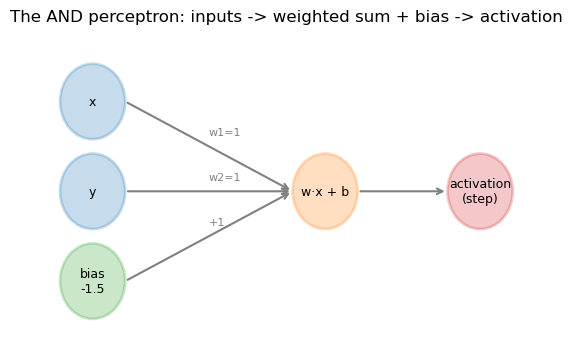

In [8]:
# A simple diagram of the AND perceptron
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axis('off')

# input nodes, bias node, output node
nodes = {'x': (0, 2), 'y': (0, 1), 'b': (0, 0), 'sum': (3, 1), 'out': (5, 1)}
labels = {'x': 'x', 'y': 'y', 'b': 'bias\n-1.5', 'sum': 'w·x + b', 'out': 'activation\n(step)'}
colors = {'x': 'C0', 'y': 'C0', 'b': 'C2', 'sum': 'C1', 'out': 'C3'}
for k, (px, py) in nodes.items():
    ax.add_patch(plt.Circle((px, py), 0.42, color=colors[k], alpha=0.25, ec=colors[k], lw=2))
    ax.text(px, py, labels[k], ha='center', va='center', fontsize=9)

# edges with weights
for src, wlabel in [('x', 'w1=1'), ('y', 'w2=1'), ('b', '+1')]:
    (sx, sy) = nodes[src]; (tx, ty) = nodes['sum']
    ax.annotate('', xy=(tx-0.42, ty), xytext=(sx+0.42, sy),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
    ax.text((sx+tx)/2, (sy+ty)/2 + 0.12, wlabel, fontsize=8, color='gray')
ax.annotate('', xy=(nodes['out'][0]-0.42, 1), xytext=(nodes['sum'][0]+0.42, 1),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.set_xlim(-1, 6); ax.set_ylim(-0.8, 2.8)
ax.set_title('The AND perceptron: inputs -> weighted sum + bias -> activation')
plt.show()

## Summary

- A **linear classifier** scores an input by a **dot product** of features with a weight vector and compares to a **threshold** — the simplest (one-layer) neural network.
- Stacking inputs into a **matrix** and multiplying by the weight vector computes **all scores at once**; more features $\Rightarrow$ wider matrix, longer weight vector.
- The threshold can be folded in as a **bias** (append a $1$-column to the data and a bias entry to the model), turning the test into *is the result $\geq 0$?*.
- A **perceptron** computes $\text{activation}(w\cdot x + b)$; with a **step** activation it reproduces the threshold classifier, and it can model logic like **AND**.
- This is why linear algebra powers neural networks: **matrix products + a non-linear activation** are the core building blocks.